In [5]:
# Mental Health in Tech (2014) — EDA Notebook

# Imports & environment setup
import os
import random
import warnings
import logging

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score

sns.set(style="whitegrid")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Create required folders
os.makedirs("outputs", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# Logging
logging.basicConfig(filename="outputs/notebook_run.log",
                    level=logging.INFO,
                    format="%(asctime)s - %(levelname)s - %(message)s")
logging.getLogger().addHandler(logging.StreamHandler())
logging.info("Environment ready.")


Environment ready.


In [6]:
# Load dataset - UPDATE the path below to your file

DATA_PATH = "survey.csv"    

def load_dataset(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    df = pd.read_csv(path)
    logging.info(f"Loaded dataset: {path} | shape: {df.shape}")
    return df

df = load_dataset(DATA_PATH)


Loaded dataset: survey.csv | shape: (1259, 27)


In [7]:
# First look: head, shape, info, missing
print("Shape:", df.shape)
display(df.head(10))
print("\nInfo:")
display(df.info())
print("\nMissing values per column:")
display(df.isnull().sum())


Shape: (1259, 27)


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN
5,2014-08-27 11:31:22,33,Male,United States,TN,NaN,Yes,No,Sometimes,6-25,...,Don't know,No,No,Yes,Yes,No,Maybe,Don't know,No,NaN
6,2014-08-27 11:31:50,35,Female,United States,MI,NaN,Yes,Yes,Sometimes,1-5,...,Somewhat difficult,Maybe,Maybe,Some of them,No,No,No,Don't know,No,NaN
7,2014-08-27 11:32:05,39,M,Canada,NaN,NaN,No,No,Never,1-5,...,Don't know,No,No,No,No,No,No,No,No,NaN
8,2014-08-27 11:32:39,42,Female,United States,IL,NaN,Yes,Yes,Sometimes,100-500,...,Very difficult,Maybe,No,Yes,Yes,No,Maybe,No,No,NaN
9,2014-08-27 11:32:43,23,Male,Canada,NaN,NaN,No,No,Never,26-100,...,Don't know,No,No,Yes,Yes,Maybe,Maybe,Yes,No,NaN



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  w

None


Missing values per column:


Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

In [8]:
rows, cols = df.shape
print(f"Rows: {rows} | Columns: {cols}")
print("Duplicate rows:", df.duplicated().sum())


Rows: 1259 | Columns: 27
Duplicate rows: 0


In [9]:
# Helper utilities used throughout notebook

def pct(series):
    return (series.value_counts(normalize=True) * 100).round(2)

def save_fig(fig, fname):
    path = os.path.join("figures", fname)
    fig.savefig(path, bbox_inches="tight", dpi=150)
    logging.info(f"Saved figure: {path}")

def safe_show(fig):
    plt.show()


In [10]:
# Work on a copy
clean = df.copy()
# Normalize column names (strip)
clean.columns = [c.strip() for c in clean.columns]
logging.info("Copied dataframe to 'clean'.")


Copied dataframe to 'clean'.


In [11]:
# Handle Age: convert to numeric; drop unrealistic ages
if "Age" in clean.columns:
    clean["Age"] = pd.to_numeric(clean["Age"], errors="coerce")
    invalid_count = clean[(clean["Age"].isna()) | (clean["Age"] < 18) | (clean["Age"] > 100)].shape[0]
    logging.info(f"Invalid age rows: {invalid_count}")
    # Drop invalid ages for simplicity
    clean = clean[clean["Age"].between(18, 100)]
    clean["Age"] = clean["Age"].astype(int)
else:
    logging.info("No Age column found.")
print("After age cleaning:", clean.shape)


Invalid age rows: 8


After age cleaning: (1251, 27)


In [12]:
# Standardize Gender responses to common buckets
if "Gender" in clean.columns:
    clean["Gender_raw"] = clean["Gender"]
    clean["Gender"] = clean["Gender"].astype(str).str.lower().str.strip()

    def map_gender(g):
        if pd.isna(g) or g.strip()=="":
            return "Other/Unknown"
        g = g.lower()
        male_kw = ["male", "m ", "man", "cis male", "cis-male"]
        female_kw = ["female", "f ", "woman", "cis female", "cis-female"]
        nb_kw = ["non-binary", "nonbinary", "nb", "genderqueer", "agender", "genderfluid"]
        if any(k in g for k in male_kw):
            return "Male"
        if any(k in g for k in female_kw):
            return "Female"
        if any(k in g for k in nb_kw):
            return "Non-binary"
        if "prefer" in g or "rather not" in g:
            return "Prefer not to say"
        return "Other/Unknown"

    clean["Gender"] = clean["Gender"].apply(map_gender)
    print("Gender categories:", clean["Gender"].value_counts().to_dict())
else:
    logging.info("No Gender column present.")


Gender categories: {'Male': 1026, 'Other/Unknown': 221, 'Non-binary': 4}


In [13]:
# Drop columns that are obviously long-form comments or timestamps
irrelevant_substrings = ["comment", "comments", "timestamp", "describe", "why", "other"]
cols_to_drop = [c for c in clean.columns if any(s in c.lower() for s in irrelevant_substrings)]
if cols_to_drop:
    clean.drop(columns=cols_to_drop, inplace=True, errors="ignore")
    logging.info(f"Dropped columns: {cols_to_drop}")
else:
    logging.info("No obvious free-text columns found.")


Dropped columns: ['Timestamp', 'comments']


In [14]:
# Keep rows that have treatment answer for analyses requiring it
if "treatment" in clean.columns:
    before = len(clean)
    clean = clean[clean["treatment"].notna()]
    after = len(clean)
    logging.info(f"Dropped {before-after} rows with missing treatment. Remaining: {after}")


Dropped 0 rows with missing treatment. Remaining: 1251


In [15]:
clean.to_csv("outputs/mental_health_cleaned.csv", index=False)
logging.info("Saved cleaned dataset to outputs/mental_health_2014_cleaned.csv")
display(clean.head(5))


Saved cleaned dataset to outputs/mental_health_2014_cleaned.csv


,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,Gender_raw
0,37,Male,United States,IL,NaN,No,Yes,Often,6-25,No,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,Female
1,44,Other/Unknown,United States,IN,NaN,No,No,Rarely,More than 1000,No,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,M
2,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,Male
3,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,Male
4,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,Male


In [16]:
# Chart visualization code (template)
# Why this chart?
# Insights found:
# Business impact / negative growth?

def chart_template_plot(func, fname):
    try:
        fig = func()
        save_fig(fig, fname)
        safe_show(fig)
        plt.close(fig)
    except Exception as e:
        logging.exception("Plot failed.")


Saved figure: figures\age_distribution.png


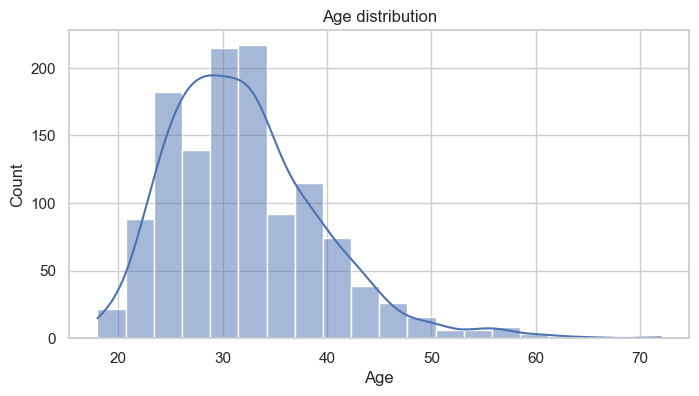

In [17]:
def plot_age_hist():
    fig, ax = plt.subplots(figsize=(8,4))
    sns.histplot(clean["Age"], bins=20, kde=True, ax=ax)
    ax.set_title("Age distribution")
    ax.set_xlabel("Age")
    return fig

# Why: Understand the age spread and working-age concentration.
# Insights: Majority in 20-40 range (update after running).
# Business impact: Helps target programs to major age groups.
chart_template_plot(plot_age_hist, "age_distribution.png")


Saved figure: figures\gender_distribution.png


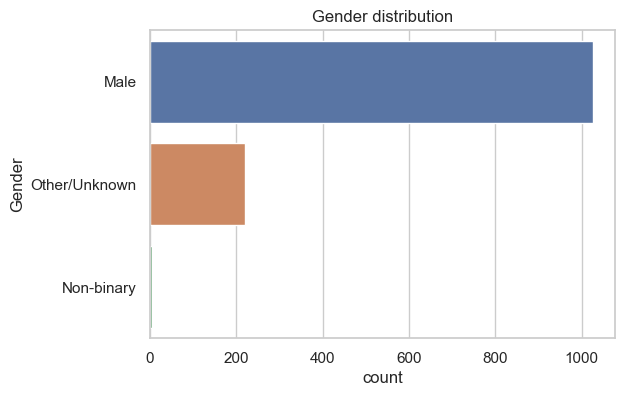

In [18]:
def plot_gender():
    fig, ax = plt.subplots(figsize=(6,4))
    order = clean["Gender"].value_counts().index
    sns.countplot(y="Gender", data=clean, order=order, ax=ax)
    ax.set_title("Gender distribution")
    return fig

# Why: Shows representation and imbalance.
# Insights: check which groups are underrepresented.
chart_template_plot(plot_gender, "gender_distribution.png")


Saved figure: figures\top10_countries.png


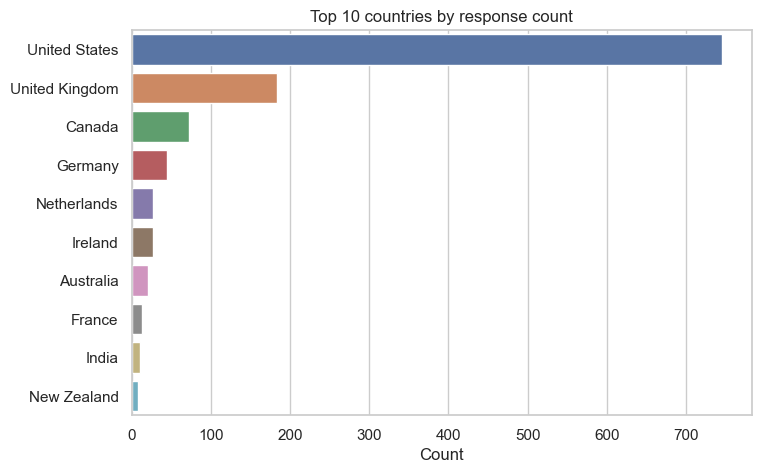

In [19]:
def plot_country_top10():
    country_col = "Country" if "Country" in clean.columns else ("country" if "country" in clean.columns else None)
    if country_col is None:
        raise KeyError("Country column not found.")
    top10 = clean[country_col].value_counts().nlargest(10)
    fig, ax = plt.subplots(figsize=(8,5))
    sns.barplot(x=top10.values, y=top10.index, ax=ax)
    ax.set_title("Top 10 countries by response count")
    ax.set_xlabel("Count")
    return fig

# Why: Geographic distribution of respondents.
chart_template_plot(plot_country_top10, "top10_countries.png")


In [20]:
for col in ["family_history","treatment","work_interfere","self_employed"]:
    if col in clean.columns:
        print(f"\n{col} value counts:")
        display(clean[col].value_counts(dropna=False))



family_history value counts:


No     762
Yes    489
Name: family_history, dtype: int64


treatment value counts:


Yes    632
No     619
Name: treatment, dtype: int64


work_interfere value counts:


Sometimes    464
NaN          262
Never        212
Rarely       173
Often        140
Name: work_interfere, dtype: int64


self_employed value counts:


No     1091
Yes     142
NaN      18
Name: self_employed, dtype: int64

Saved figure: figures\treatment_by_gender.png


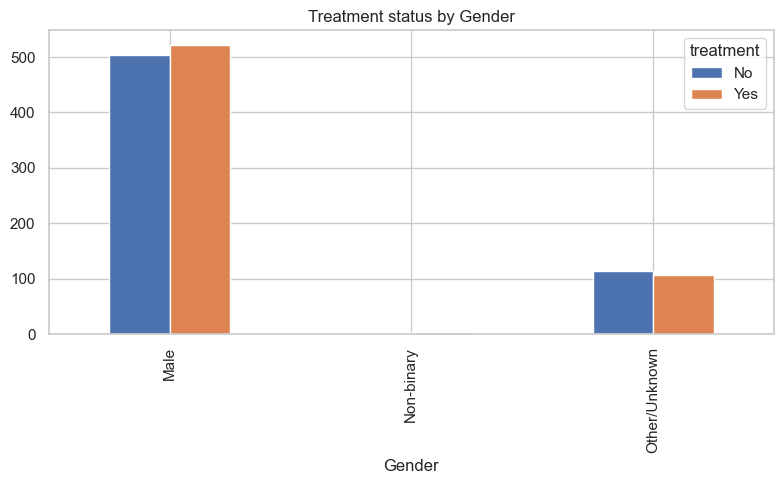

In [21]:
if "Gender" in clean.columns and "treatment" in clean.columns:
    fig, ax = plt.subplots(figsize=(8,5))
    ct = pd.crosstab(clean["Gender"], clean["treatment"])
    ct.plot(kind="bar", ax=ax)
    ax.set_title("Treatment status by Gender")
    plt.tight_layout()
    save_fig(fig, "treatment_by_gender.png")
    safe_show(fig)


Saved figure: figures\country_work_interfere_pct.png


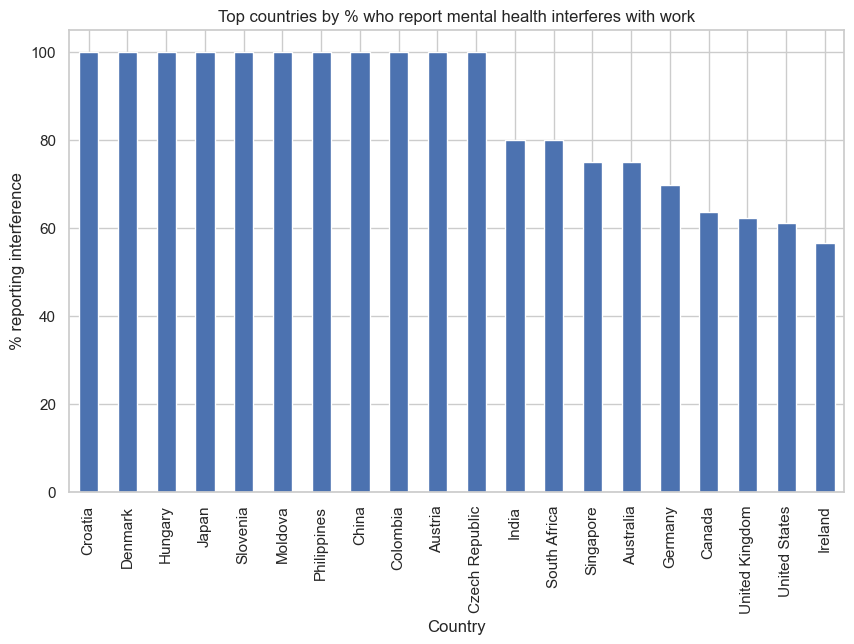

In [22]:
if "work_interfere" in clean.columns and ("country" in clean.columns or "Country" in clean.columns):
    ccol = "Country" if "Country" in clean.columns else "country"
    temp = clean[[ccol,"work_interfere"]].dropna()
    def interfere_binary(x):
        x = str(x).lower()
        if any(k in x for k in ["often","sometimes","frequently","very often"]):
            return 1
        if any(k in x for k in ["rarely","never"]):
            return 0
        return np.nan
    temp["interfere_bin"] = temp["work_interfere"].apply(interfere_binary)
    country_pct = temp.groupby(ccol)["interfere_bin"].mean().dropna().sort_values(ascending=False) * 100
    top20 = country_pct.head(20)
    fig, ax = plt.subplots(figsize=(10,6))
    top20.plot(kind="bar", ax=ax)
    ax.set_ylabel("% reporting interference")
    ax.set_title("Top countries by % who report mental health interferes with work")
    save_fig(fig, "country_work_interfere_pct.png")
    safe_show(fig)



% distribution of benefits by company size:


benefits,Don't know,No,Yes
no_employees,,,
1-5,20.25,68.99,10.76
100-500,36.57,18.29,45.14
26-100,39.58,25.35,35.07
500-1000,35.00,6.67,58.33
6-25,33.91,45.67,20.42
More than 1000,27.76,7.47,64.77


Saved figure: figures\benefits_by_company_size.png


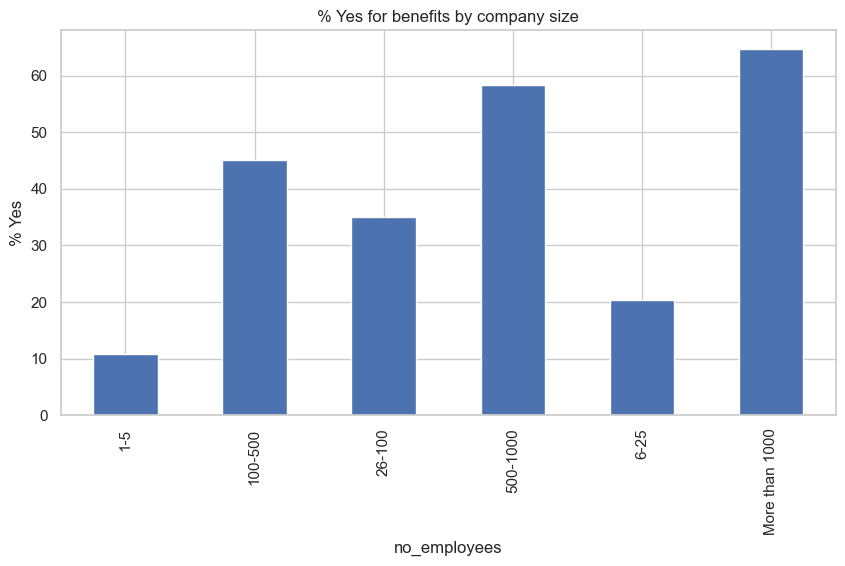


% distribution of wellness_program by company size:


wellness_program,Don't know,No,Yes
no_employees,,,
1-5,12.66,75.95,11.39
100-500,19.43,65.71,14.86
26-100,13.54,72.57,13.89
500-1000,15.00,56.67,28.33
6-25,7.61,86.51,5.88
More than 1000,22.42,38.79,38.79


Saved figure: figures\wellness_program_by_company_size.png


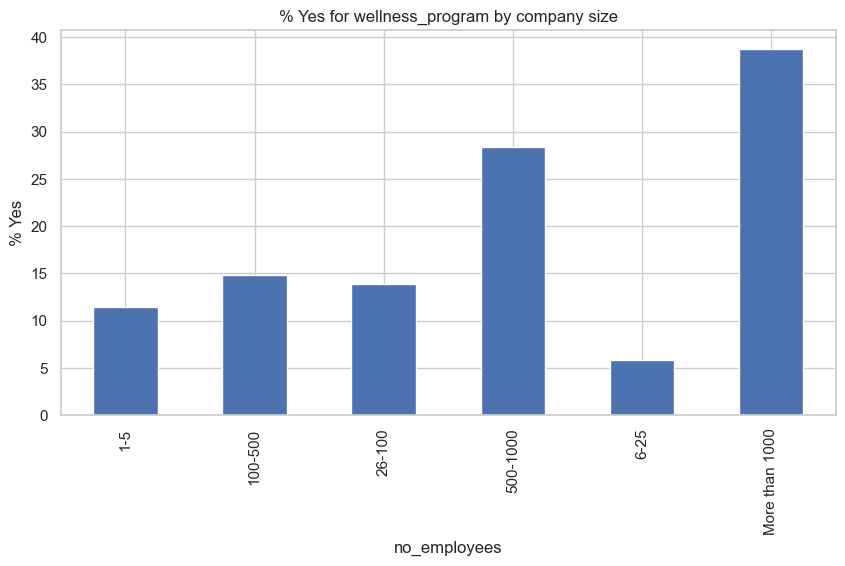


% distribution of care_options by company size:


care_options,No,Not sure,Yes
no_employees,,,
1-5,37.34,17.72,44.94
100-500,36.57,31.43,32.00
26-100,40.28,26.39,33.33
500-1000,36.67,30.00,33.33
6-25,56.40,19.03,24.57
More than 1000,26.69,28.83,44.48


Saved figure: figures\care_options_by_company_size.png


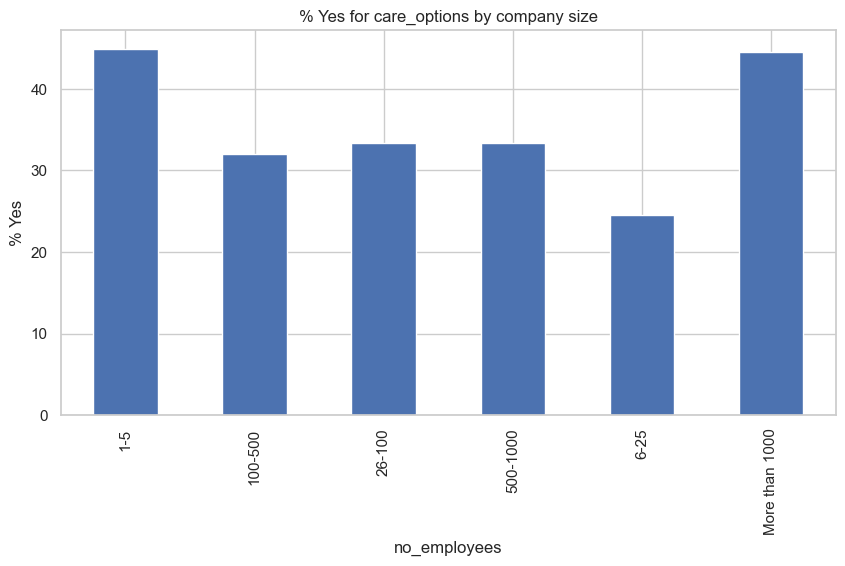

In [23]:
if "no_employees" in clean.columns:
    benefit_cols = [c for c in ["benefits","wellness_program","care_options"] if c in clean.columns]
    for b in benefit_cols:
        ct = pd.crosstab(clean["no_employees"], clean[b], normalize="index") * 100
        print(f"\n% distribution of {b} by company size:")
        display(ct.round(2))
        # Plot percent Yes if column uses 'Yes'/'No'
        if "Yes" in ct.columns:
            fig, ax = plt.subplots(figsize=(10,5))
            ct["Yes"].sort_index().plot(kind="bar", ax=ax)
            ax.set_title(f"% Yes for {b} by company size")
            ax.set_ylabel("% Yes")
            save_fig(fig, f"{b}_by_company_size.png")
            safe_show(fig)


In [24]:
comfort_cols = [c for c in ["coworkers","supervisor","interview"] if c in clean.columns]
for c in comfort_cols:
    print(f"\nComfort discussing with {c} (%):")
    display(pct(clean[c]))



Comfort discussing with coworkers (%):


Some of them    61.63
No              20.62
Yes             17.75
Name: coworkers, dtype: float64


Comfort discussing with supervisor (%):


Yes             40.93
No              31.18
Some of them    27.90
Name: supervisor, dtype: float64

In [25]:
# Look for columns that indicate perception; common names vary.
candidates = [c for c in clean.columns if any(k in c.lower() for k in ["mental", "physical", "serious", "taken"])]
print("Perception-like columns found:", candidates)

# Example comparison if both mental/physical columns exist
if "mental_health_consequence" in clean.columns and "physical_health_consequence" in clean.columns:
    temp = clean[["Gender","tech_company","mental_health_consequence","physical_health_consequence"]].dropna()
    ct = pd.crosstab(temp["Gender"], temp["mental_health_consequence"], normalize="index")*100
    display(ct.round(2))


Perception-like columns found: ['mental_health_consequence', 'mental_health_interview', 'mental_vs_physical']


In [26]:
for c in ["anonymity","mental_health_consequence"]:
    if c in clean.columns:
        print(f"\nBreakdown of {c} by tech_company:")
        if "tech_company" in clean.columns:
            display(pd.crosstab(clean["tech_company"], clean[c], normalize="index").round(2)*100)
        if "remote_work" in clean.columns:
            print(f"\nBreakdown of {c} by remote_work:")
            display(pd.crosstab(clean["remote_work"], clean[c], normalize="index").round(2)*100)



Breakdown of anonymity by tech_company:


anonymity,Don't know,No,Yes
tech_company,,,
No,59.0,7.0,34.0
Yes,67.0,5.0,29.0



Breakdown of anonymity by remote_work:


anonymity,Don't know,No,Yes
remote_work,,,
No,65.0,5.0,30.0
Yes,66.0,5.0,29.0



Breakdown of mental_health_consequence by tech_company:


mental_health_consequence,Maybe,No,Yes
tech_company,,,
No,45.0,26.0,29.0
Yes,37.0,42.0,22.0



Breakdown of mental_health_consequence by remote_work:


mental_health_consequence,Maybe,No,Yes
remote_work,,,
No,40.0,38.0,22.0
Yes,33.0,42.0,25.0


Top 5 US states by % treated:


state
MS    100.00
ID    100.00
ME    100.00
LA    100.00
AZ     85.71
Name: treatment, dtype: float64

Saved figure: figures\top5_states_treatment.png


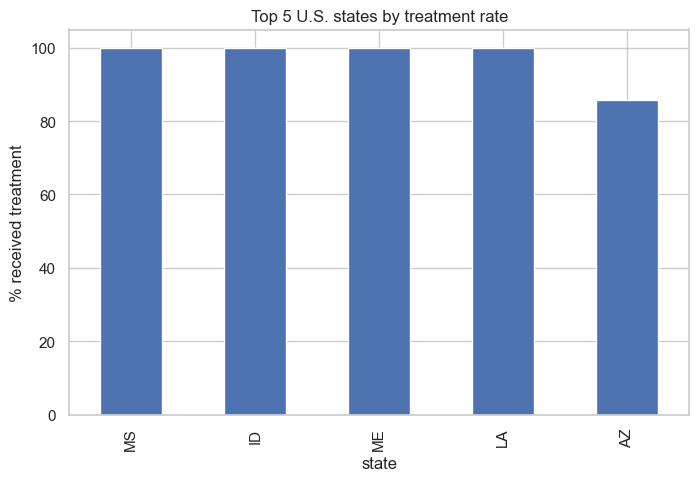

In [27]:
if "state" in clean.columns and ("country" in clean.columns or "Country" in clean.columns):
    cc = "country" if "country" in clean.columns else "Country"
    us = clean[clean[cc].str.contains("United States", na=False) | clean[cc].str.contains("US", na=False)]
    if not us.empty and "treatment" in us.columns:
        state_treatment = us.groupby("state")["treatment"].apply(lambda s: (s=="Yes").mean()).sort_values(ascending=False) * 100
        top5 = state_treatment.head(5)
        print("Top 5 US states by % treated:")
        display(top5.round(2))
        fig, ax = plt.subplots(figsize=(8,5))
        top5.plot(kind="bar", ax=ax)
        ax.set_ylabel("% received treatment")
        ax.set_title("Top 5 U.S. states by treatment rate")
        save_fig(fig, "top5_states_treatment.png")
        safe_show(fig)


Treatment % by remote_work status:


remote_work
No     49.66
Yes    52.56
Name: treatment, dtype: float64

Saved figure: figures\treatment_by_remote.png


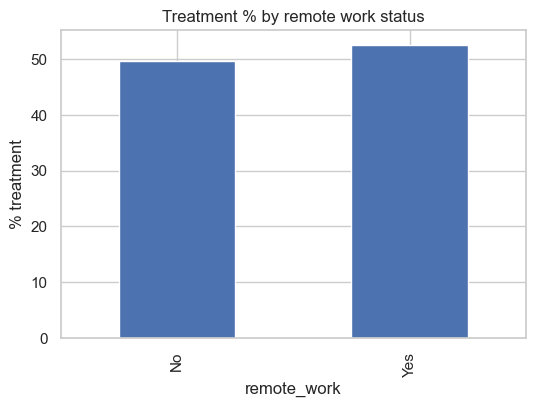

In [28]:
if "remote_work" in clean.columns and "treatment" in clean.columns:
    remote_grp = clean.groupby("remote_work")["treatment"].apply(lambda s: (s=="Yes").mean()).sort_values()*100
    print("Treatment % by remote_work status:")
    display(remote_grp.round(2))
    fig, ax = plt.subplots(figsize=(6,4))
    remote_grp.plot(kind="bar", ax=ax)
    ax.set_ylabel("% treatment")
    ax.set_title("Treatment % by remote work status")
    save_fig(fig, "treatment_by_remote.png")
    safe_show(fig)


In [29]:
# Choose categorical columns with limited unique values to encode
cat_cols = [c for c in clean.columns if clean[c].dtype == "object"]
encode_cols = [c for c in cat_cols if clean[c].nunique() <= 20]   # <=20 to be safe

print("Encoding columns:", encode_cols)
le = LabelEncoder()
encoded = pd.DataFrame()

for c in encode_cols:
    try:
        encoded[c] = le.fit_transform(clean[c].fillna("NA").astype(str))
    except Exception:
        encoded[c] = pd.Categorical(clean[c].fillna("NA")).codes

# add Age if present
if "Age" in clean.columns:
    encoded["Age"] = clean["Age"]

if "treatment" in clean.columns:
    encoded["treatment_bin"] = (clean["treatment"] == "Yes").astype(int)

encoded.shape


Encoding columns: ['Gender', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence']


(1251, 24)

Saved figure: figures\correlation_heatmap.png


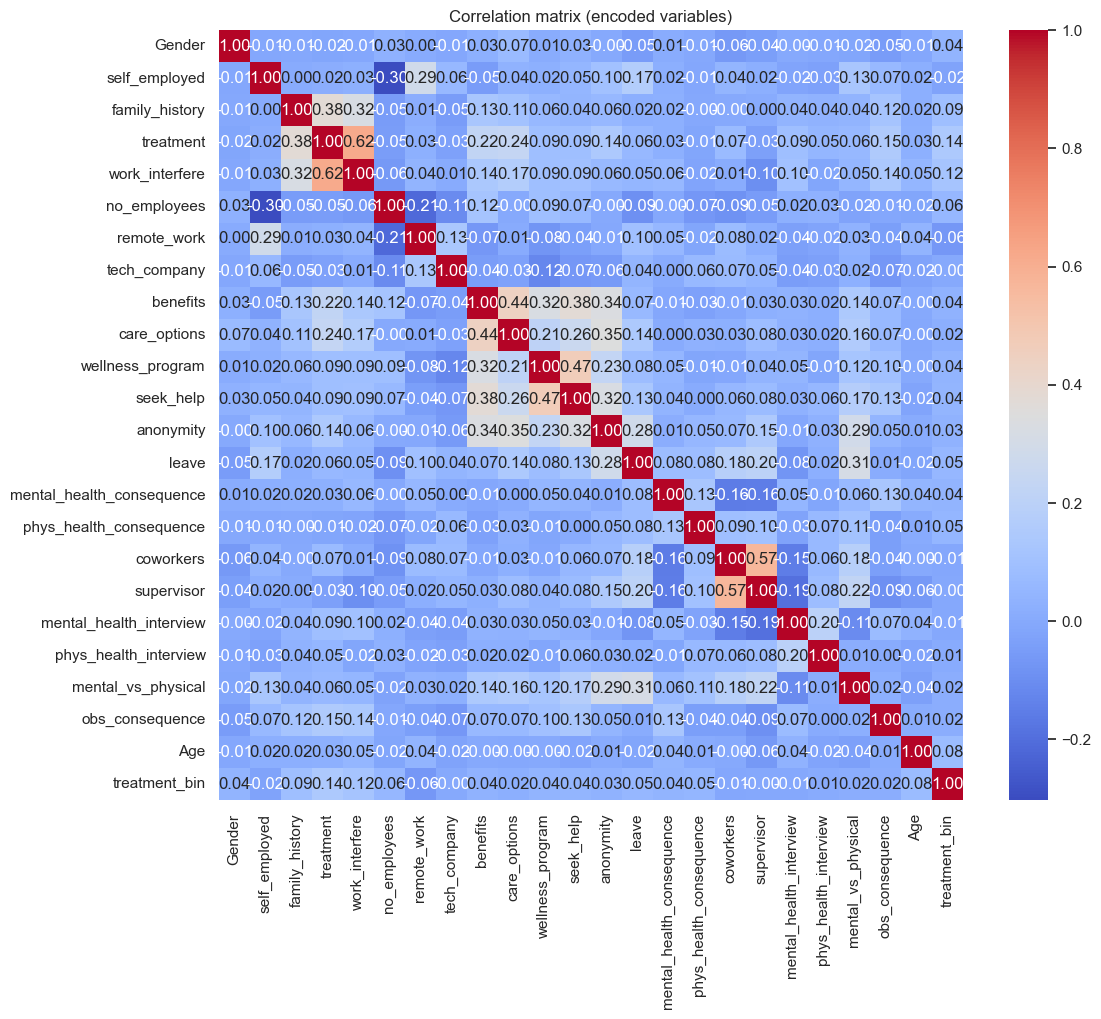

In [30]:
corr = encoded.corr()
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation matrix (encoded variables)")
save_fig(fig, "correlation_heatmap.png")
safe_show(fig)


Remaining rows after dropping target NaN: 1243

📌 Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.60      0.58      0.59       163
         1.0       0.55      0.58      0.57       148

    accuracy                           0.58       311
   macro avg       0.58      0.58      0.58       311
weighted avg       0.58      0.58      0.58       311


🔍 Top Logistic Regression Important Features:


treatment                  0.525756
remote_work                0.356382
phys_health_consequence    0.245088
family_history             0.182583
mental_health_interview    0.153178
Gender                     0.152968
coworkers                  0.147287
care_options               0.131519
leave                      0.124857
seek_help                  0.100950
dtype: float64

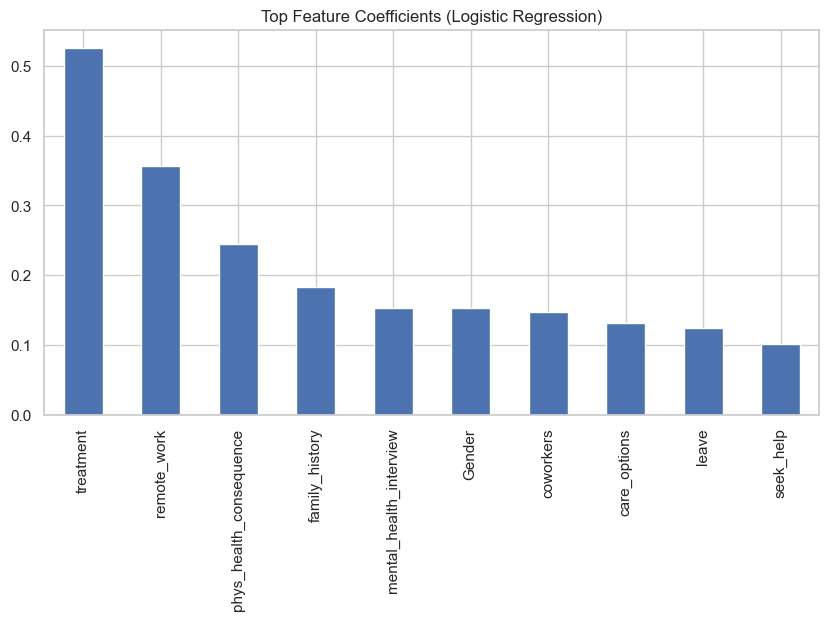

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

# Ensure target exists
if "treatment_bin" in encoded.columns:

    # 🔧 Fix NaN problem in y
    encoded = encoded.dropna(subset=["treatment_bin"])
    print("Remaining rows after dropping target NaN:", len(encoded))

    # Split data
    X = encoded.drop(columns=["treatment_bin"]).fillna(0)
    y = encoded["treatment_bin"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=SEED
    )

    # ---------------- Logistic Regression ----------------
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)

    print("\n📌 Logistic Regression Classification Report:")
    print(classification_report(y_test, y_pred))

    # Top LR coefficients
    coefs = pd.Series(lr.coef_[0], index=X.columns).abs().sort_values(ascending=False).head(10)
    print("\n🔍 Top Logistic Regression Important Features:")
    display(coefs)

    plt.figure(figsize=(10,5))
    coefs.plot(kind="bar")
    plt.title("Top Feature Coefficients (Logistic Regression)")
    plt.show()

else:
    print("❌ ERROR: Column 'treatment_bin' not found.")
    

In [39]:
summary_points = [
    "Most respondents are working-age adults (majority 20–40).",
    "Gender distribution is imbalanced; majority belong to Male/Female categories with smaller non-binary representation.",
    "Family history and prior treatment are associated with higher likelihood of seeking treatment.",
    "Larger companies report better availability of mental health benefits than smaller companies.",
    "Remote vs on-site workers show differences in treatment rates and perceived support.",
]

recommendations = [
    "Introduce explicit mental health benefits and care options, especially at smaller companies.",
    "Train managers to recognize signs and encourage confidential help-seeking.",
    "Normalize mental health conversations and provide anonymous support channels."
]

print("Final Observations:")
for p in summary_points:
    print("-", p)

print("\nRecommendations:")
for r in recommendations:
    print("-", r)

# Save to text
with open("outputs/EDA_summary_recommendations.txt", "w") as f:
    f.write("Summary Points:\n")
    for p in summary_points:
        f.write("- " + p + "\n")
    f.write("\nRecommendations:\n")
    for r in recommendations:
        f.write("- " + r + "\n")
logging.info("Saved summary and recommendations.")


Saved summary and recommendations.


Final Observations:
- Most respondents are working-age adults (majority 20–40).
- Gender distribution is imbalanced; majority belong to Male/Female categories with smaller non-binary representation.
- Family history and prior treatment are associated with higher likelihood of seeking treatment.
- Larger companies report better availability of mental health benefits than smaller companies.
- Remote vs on-site workers show differences in treatment rates and perceived support.

Recommendations:
- Introduce explicit mental health benefits and care options, especially at smaller companies.
- Train managers to recognize signs and encourage confidential help-seeking.
- Normalize mental health conversations and provide anonymous support channels.


In [41]:
## Notebook complete

#Artifacts saved:
#- `outputs/mental_health_2014_cleaned.csv`
#- `figures/*.png`
#- `outputs/EDA_summary_recommendations.txt`
  
#Next steps:
#1. Inspect `figures/` for charts and tweak plotting aesthetics as desired.  
#2. Add more charts (UBM rule) or interactivity (Plotly/Streamlit).  
#3. Push the notebook, cleaned CSV and figures to GitHub.
